# Notebook Explanation: Testing a Conventional Baseline Under Biased Business Data

This notebook tests the failure mode described in the P34 / PARML paper: a conventional model can look strong when evaluated only on historically observed business trades, yet fail when deployed against the full opportunity menu.

The core issue is selection bias. In real business data, the company usually knows reliable outcomes only for the actions it actually took, or for safely grounded variants of those actions. It does not observe clean labels for every opportunity it could have taken. Therefore, the historical dataset is not a random sample of the market. It is the result of a prior business policy that already tried to select good trades.

This notebook creates a synthetic market where that problem is visible and measurable. It then trains an industry-style baseline model on the business-observed data and compares two evaluations:

1. **Naive business-observed evaluation**: score only the kinds of trades the business historically observed.
2. **Deploy-time simulation**: score the full future opportunity menu, including opportunities that were not historically observed.

The expected behavior is that the naive evaluation looks profitable, while the deploy-time simulation exposes hidden false positives.


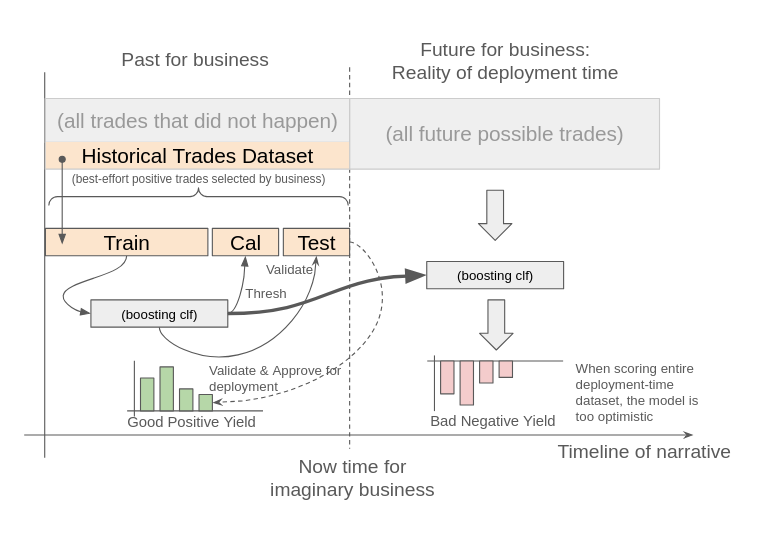

In [ ]:
from IPython.display import Image, display
display(Image(filename="problem_statement.png"))

<div style="font-size: 18px;">
Imports
</div>

In [1]:
# set cwd to .parml2
import os
os.chdir("p34-technical-report")

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")
from IPython.display import display

from market_synth import (
    ModernMarketSynthConfig,
    convert_market_dataset_state,
    get_market_dataset,
    save_market_dataset,
)

## Market Configuration

This section defines the synthetic market used for the test.

The configuration intentionally creates a market with slower market waves, changing profitability, hidden demand variation, downside regimes, operational costs, and a biased business-selection policy. These settings are designed to reproduce the kind of environment described in the P34 paper: a computable market where actions are measurable, but the true market signal is not directly available as a clean data feed.

Important elements in this configuration:

* `market_observed_period` and `market_latent_period` create slow market cycles.
* `market_profit_trend_strength` creates a profitability trend that can make historical relationships less reliable in the future.
* `downside_regime_*` parameters create hidden downside risk.
* `policy_threshold_*` and `policy_score_noise_scale` define the historical business policy that decides which opportunities become observed.
* `policy_exploration_accept_rate=0.01` means the business accepts a small number of exploratory trades, but most observations still come from a biased selection process.

In the language of the paper, this is not meant to be a perfectly realistic market simulator. It is a controlled testbed for isolating partial observability, biased labels, regime drift, and false-positive risk.


In [3]:
random_state = 42

config = ModernMarketSynthConfig(
    # Market Wave
    market_observed_period=100.0,
    market_latent_period=100.0,
    market_trend_segments=None,

    # Price / Cost / Volume
    cluster_sv_range=(0.01, 3.0),
    lcogs_floor_base=18.0,
    lcogs_floor_amplitude=8.50,
    base_price=34.0,
    lcogs_draw_skew=1,
    volume_amplitude=0.65,
    holding_cost_per_unit=0.5,
    leftover_writeoff_fraction=1,
    market_profit_trend_strength=1.75,

    # Hidden Demand / Downside Risk
    latent_offer_edge_noise_scale=0.18,
    latent_offer_fragility_noise_scale=0.10,
    downside_regime_base_prob=0.01,
    downside_regime_max_prob=0.28,
    downside_regime_best_demand_mult=0.90,
    downside_regime_worst_demand_mult=0.10,
    downside_regime_max_extra_cost_frac=0.55,
    market_latent_amplitude=0.16,
    market_latent_noise_amplitude=0.10,

    # Business Selection Policy
    policy_threshold_base=1.90,
    policy_threshold_amplitude=0.30,
    policy_threshold_noise_amplitude=0.08,
    policy_score_noise_scale=0.75,
    policy_exploration_accept_rate=0.01,
    business_operational_cost_per_unit=2.5,
    mid_sv_threshold=3.0,

    # note: more knobs are available in ModernMarketSynthConfig defaults for full control
)

## Simulate Business Data

This section generates the synthetic market dataset.

The generated data contains both:

* **observed / labeled rows**, representing actions the business historically took or safely grounded; and
* **unobserved / unlabeled rows**, representing options that existed in the market menu but were not chosen by the historical business policy.

This distinction is central to the P34 problem. A normal supervised-learning model usually trains only on the labeled rows. But at deployment time, the model faces a much wider menu of candidate actions. If the labeled rows are biased toward historically selected trades, the model may overestimate profitability when it is exposed to the full menu.

In [4]:
market_dataset = get_market_dataset(
    random_state=random_state,
    config=config,
)

100%|██████████| 30/30 [00:13<00:00,  2.26it/s]


Generated 3931200 telemetry points.
Policy exploration accepts: 180 / 18,068 accepted-by-policy (1.00%) vs target 1.00% [requested picks=180]
Min date in X_test: 80.0
Max date in X_train: 79.0
Min date in X_test: 80.0
Max date in X_train: 79.0


## Data Inspection

This section reconstructs the training and evaluation views needed to inspect the market.

The notebook combines historical observed rows, historical unobserved rows, future observed rows, and future unobserved rows into inspection frames. This allows us to compare what the business historically saw against what the full market actually contained.

The important idea is that the model does not get clean access to the full truth during training. The full market is available here only because this is a synthetic benchmark. That lets us measure the gap between the business-observed sample and the actual deployment-time opportunity set.

<div style="font-size: 18px;">
Prepare data for inspection
</div>

In [5]:
inspection = market_dataset["inspection"]
rng = np.random.default_rng(random_state)

hist_observed = inspection["hist_observed"]
hist_unobserved = inspection["hist_unobserved"]
train_all = inspection["train_all"]
eval_all = inspection["eval_all"]
inspect_all = inspection["inspect_all"]

segment_colors = {"observed": "orange", "unobserved": "darkgray"}
train_eval_boundary_week = float(eval_all["date"].min())

## Business Acceptance Rate by Week

This chart shows how often the historical business policy accepted opportunities over time.

The acceptance rate is not random. It changes with market conditions and with the hidden business policy. This matters because the labeled dataset is created by this policy. When the policy accepts more opportunities, more outcomes become visible. When it rejects opportunities, those outcomes remain unobserved.

This is one of the main reasons ordinary holdout testing can be misleading. If both training and testing are drawn from the same policy-filtered data, the model may appear strong while still failing on the wider deployment menu.


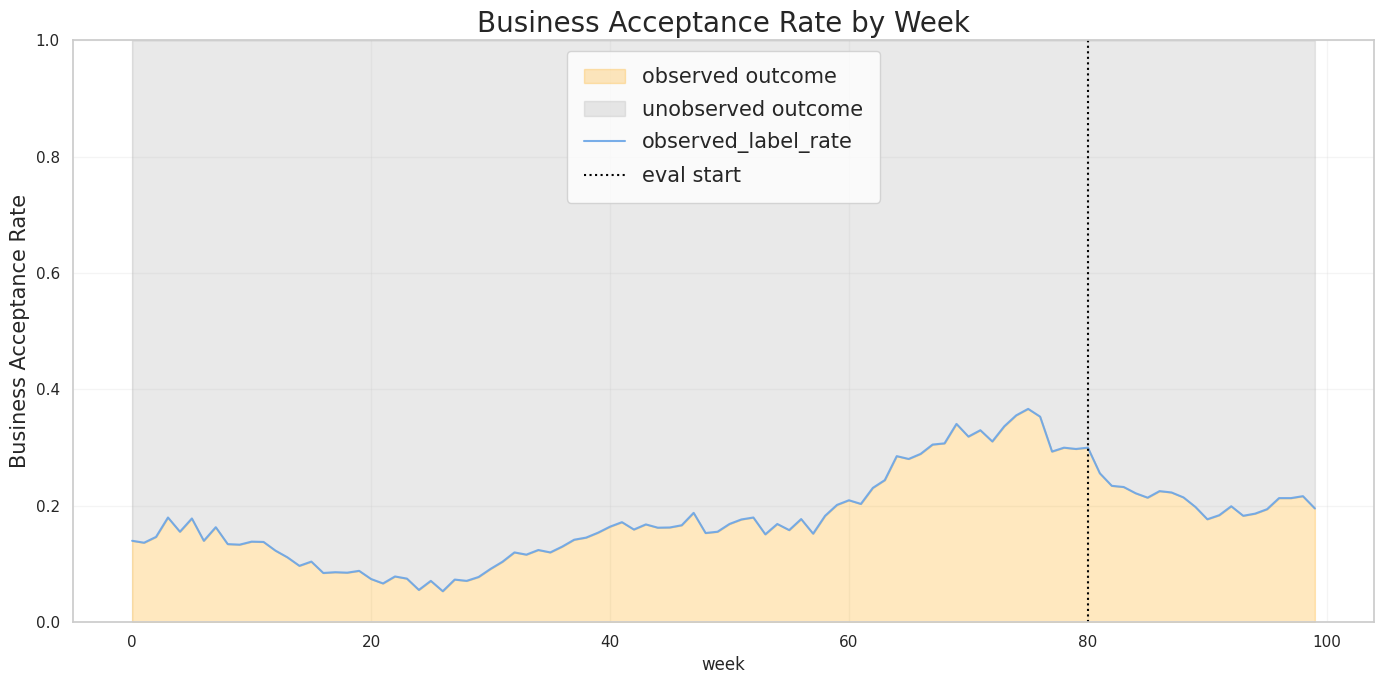

In [6]:
label_rate_by_week = (
    inspect_all[["date", "key", "segment"]]
    .drop_duplicates(["date", "key"])
    .groupby("date")
    .agg(observed_label_rate=("segment", lambda s: (s == "observed").mean()))
    .reset_index()
)
fig, ax = plt.subplots(figsize=(14, 7))

x = label_rate_by_week["date"]
y = label_rate_by_week["observed_label_rate"]
ax.fill_between(x, 0, y, color=segment_colors["observed"], alpha=0.25, label="observed outcome")
ax.fill_between(x, y, 1, color=segment_colors["unobserved"], alpha=0.25, label="unobserved outcome")
ax.plot(x, y, color="#6aa5e7", lw=1.5, alpha=0.9, label="observed_label_rate")
ax.set_title("Business Acceptance Rate by Week", fontsize=20)
ax.set_xlabel("week")
ax.set_ylim(0, 1)
ax.set_ylabel("Business Acceptance Rate", fontsize=15)
ax.axvline(train_eval_boundary_week, color="black", ls=":", lw=1.5, label="eval start")
ax.grid(alpha=0.2)
ax.legend(fontsize=15, frameon=True, borderpad=0.8, labelspacing=0.6)
plt.tight_layout()

## Row Count by Week
This chart counts grounded rows by week, split into observed and unobserved segments.

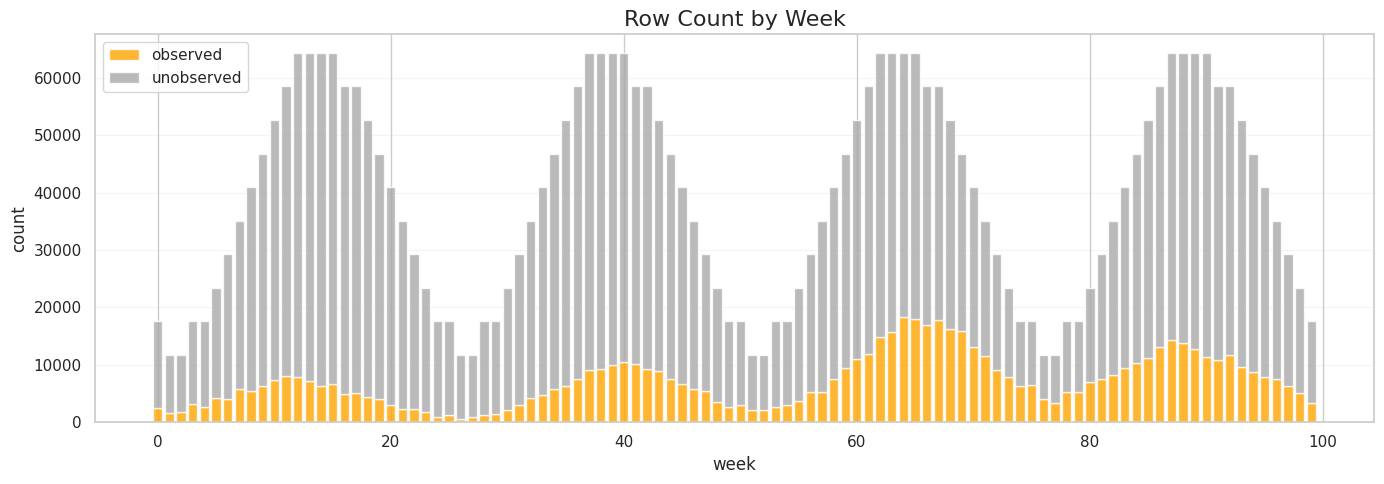

In [7]:
count_by_date = (
    inspect_all
    .groupby(["date", "segment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["observed", "unobserved"], fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    count_by_date.index,
    count_by_date["observed"],
    label="observed",
    color=segment_colors["observed"],
    alpha=0.8,
)
ax.bar(
    count_by_date.index,
    count_by_date["unobserved"],
    bottom=count_by_date["observed"],
    label="unobserved",
    color=segment_colors["unobserved"],
    alpha=0.8,
)

ax.set_title("Row Count by Week", fontsize=16)
ax.set_xlabel("week")
ax.set_ylabel("count")
ax.grid(alpha=0.2, axis="y")
ax.legend()
plt.tight_layout()

## Profit Distribution

This section compares profit distributions for observed and unobserved rows.

The key diagnostic is whether observed rows and unobserved rows have different profit distributions. If they do, the historical business data is biased. A model trained only on observed rows is not learning from the full market distribution. It is learning from the subset that the business policy allowed it to see.

This reproduces the paper's central real-world problem: businesses usually observe the outcomes of selected actions, not the outcomes of all available actions.


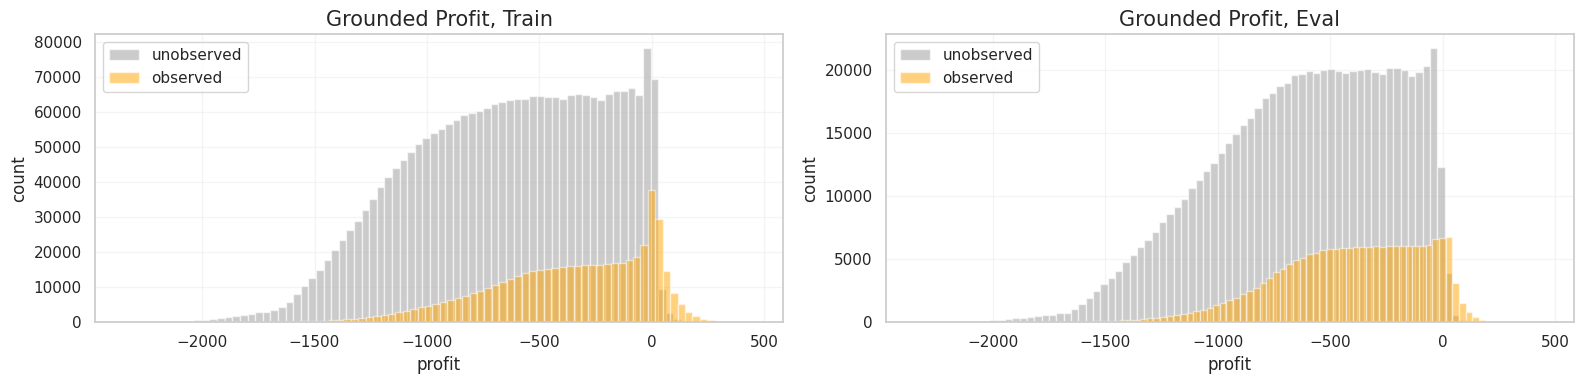

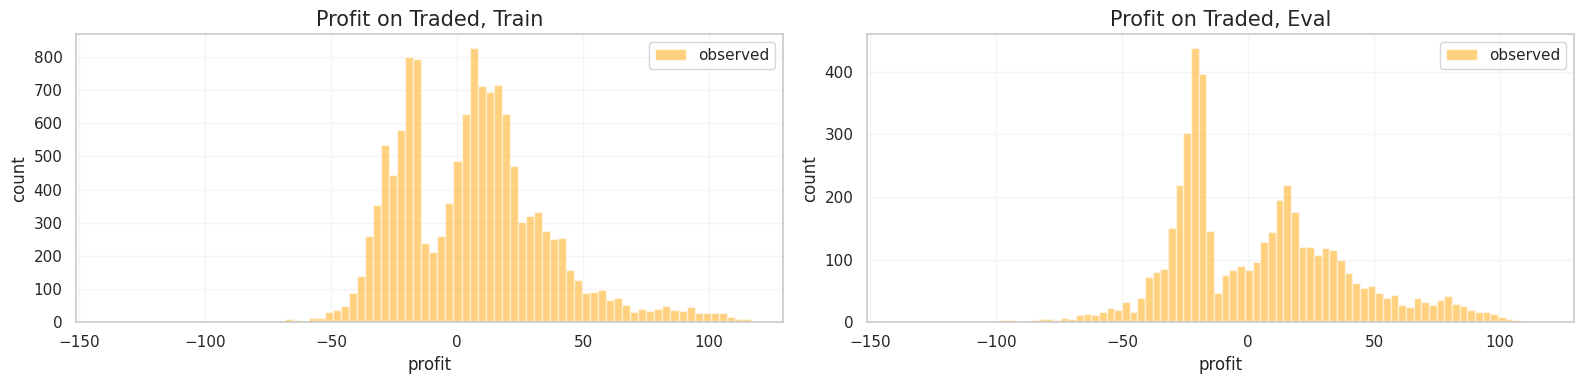

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, df, title in [
    (axes[0], train_all, "Grounded Profit, Train"),
    (axes[1], eval_all, "Grounded Profit, Eval"),
]:
    ax.hist(df.loc[df["segment"] == "unobserved", "profit"], bins=80, alpha=0.6, label="unobserved", color=segment_colors["unobserved"])
    ax.hist(df.loc[df["segment"] == "observed", "profit"], bins=80, alpha=0.5, label="observed", color=segment_colors["observed"])
    ax.set(xlabel="profit", ylabel="count")
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, df, title in [
    (axes[0], train_all[train_all["is_business_chosen_qty"] & train_all["segment"].eq("observed")], "Profit on Traded, Train"),
    (axes[1], eval_all[eval_all["is_business_chosen_qty"] & eval_all["segment"].eq("observed")], "Profit on Traded, Eval"),
]:
    ax.hist(df["profit"], bins=80, alpha=0.5, label="observed", color=segment_colors["observed"])
    ax.set(xlabel="profit", ylabel="count")
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

## Profit by Week

This chart shows how average profit changes over time for business-traded observed rows.

The purpose is to inspect market drift. If profitability changes across weeks, then a model trained on past observed trades may not generalize to future opportunities. This is especially dangerous when the model is deployed into a broader menu than the one represented in the training data.

In the paper's terminology, this is the interaction between selection bias and regime change. The model can learn a historical pattern that was true for prior accepted trades but becomes unsafe under future market conditions.


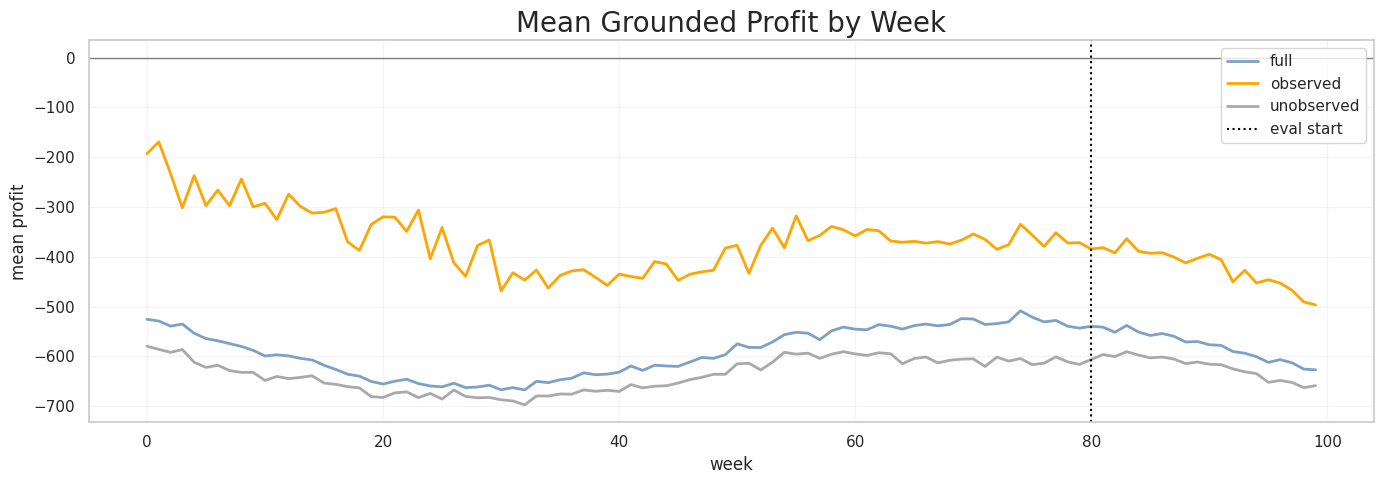

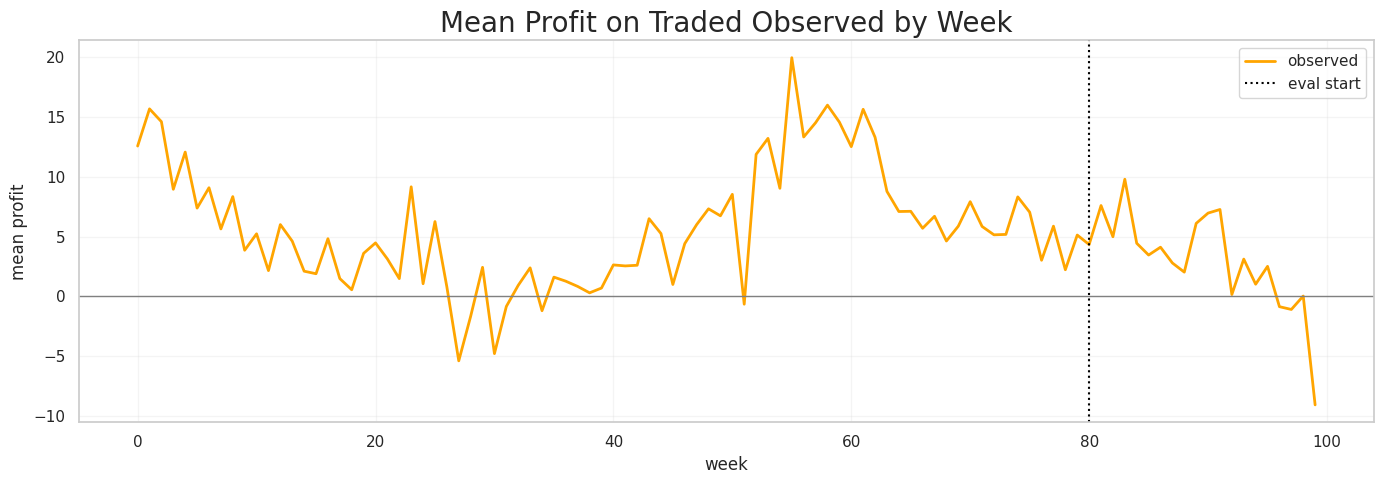

In [9]:
profit_by_week = {}
for name, df in [("grounded", inspect_all), ("traded", inspect_all[inspect_all["is_business_chosen_qty"]])]:
    profit_by_week[name] = (
        df.groupby("date")["profit"].mean().rename("full").to_frame()
        .join(df.groupby(["date", "segment"])["profit"].mean().unstack("segment"))
        .reset_index()
    )
grounded_profit_by_week = profit_by_week["grounded"]
traded_profit_by_week = profit_by_week["traded"]

grounded_plot = grounded_profit_by_week.copy()
grounded_cols = ["full", "observed", "unobserved"]
grounded_colors = {"full": "#7CA1C4", **segment_colors}

fig, ax = plt.subplots(figsize=(14, 5))
for col in grounded_cols:
    ax.plot(grounded_plot["date"], grounded_plot[col], lw=2, label=col, color=grounded_colors[col])

ax.axhline(0, c="gray", lw=1)
ax.axvline(train_eval_boundary_week, color="black", ls=":", lw=1.5, label="eval start")
ax.set_title("Mean Grounded Profit by Week", fontsize=20)
ax.set_xlabel("week")
ax.set_ylabel("mean profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

profit_by_week = traded_profit_by_week
col = "observed"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(profit_by_week["date"], profit_by_week[col], lw=2, label=col, color=segment_colors[col])

ax.axhline(0, c="gray", lw=1)
ax.axvline(train_eval_boundary_week, color="black", ls=":", lw=1.5, label="eval start")
ax.set_title("Mean Profit on Traded Observed by Week", fontsize=20)
ax.set_xlabel("week")
ax.set_ylabel("mean profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

<div style="font-size: 18px;">
Features
</div>

In [10]:
baseline_feature_cols = ["lcogs", "qty", "sv", "isv"]
observed_baseline_features = hist_observed[baseline_feature_cols]
display(observed_baseline_features.describe().round(2))

,lcogs,qty,sv,isv
count,521313.00,521313.00,521313.00,521313.00
mean,23.47,20.00,1.74,8.36
std,7.22,11.25,1.66,21.95
min,9.50,1.00,0.01,0.23
25%,17.25,10.00,0.25,0.24
50%,24.35,20.00,1.06,0.94
75%,28.87,30.00,4.22,3.97
max,37.97,39.00,4.36,152.82


## Policy Score

Policy Score represents a score the business historically used to decide whether to accept an opportunity.

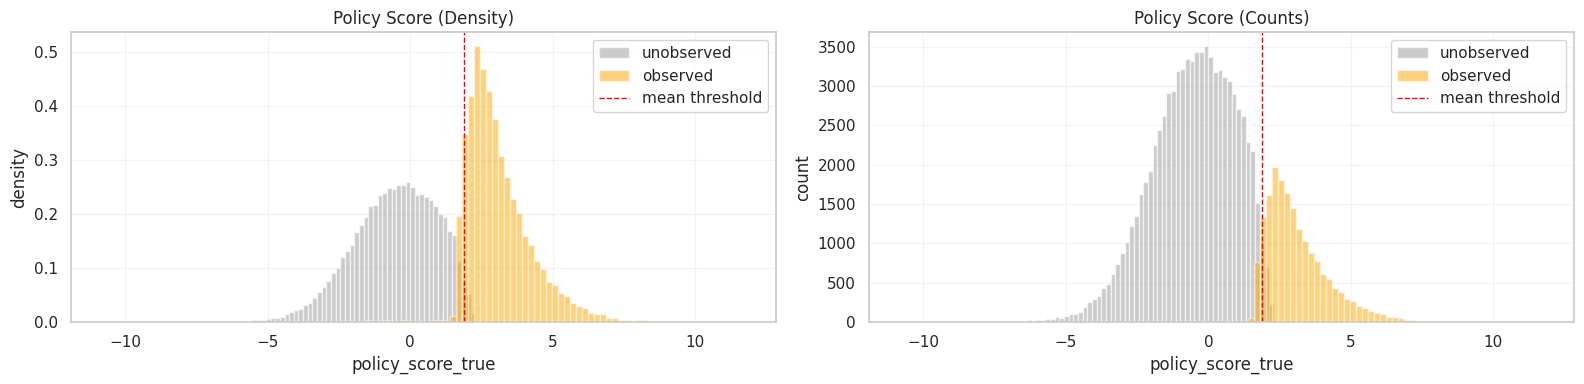

In [11]:
policy_df = inspection["key_policy_df"]
score_threshold = float(policy_df["policy_threshold_t"].mean())
observed_scores = policy_df.loc[policy_df["accepted"], "policy_score_true"]
unobserved_scores = policy_df.loc[~policy_df["accepted"], "policy_score_true"]

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, density, ylabel, title in [
    (axes[0], True, "density", "Policy Score (Density)"),
    (axes[1], False, "count", "Policy Score (Counts)"),
]:
    ax.hist(unobserved_scores, bins=80, alpha=0.6, label="unobserved", density=density, color=segment_colors["unobserved"])
    ax.hist(observed_scores, bins=80, alpha=0.5, label="observed", density=density, color=segment_colors["observed"])
    ax.axvline(score_threshold, color="red", ls="--", lw=1, label="mean threshold")
    ax.set(title=title, xlabel="policy_score_true", ylabel=ylabel)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

## Profit Sensitivity to Quantity

This section plots profit curves by quantity for sampled keys.

The curves show why quantity must be treated as part of the action space. Profit is often non-monotonic: buying more units may improve gross profit at first, then create losses because of excess inventory, writeoffs, holding costs, or demand limits.

This connects directly to the paper's boundary-aware sizing argument. A trading decision is not only "buy or do not buy." It is also "how much should be bought?" A correct model must evaluate trade selection and sizing together.


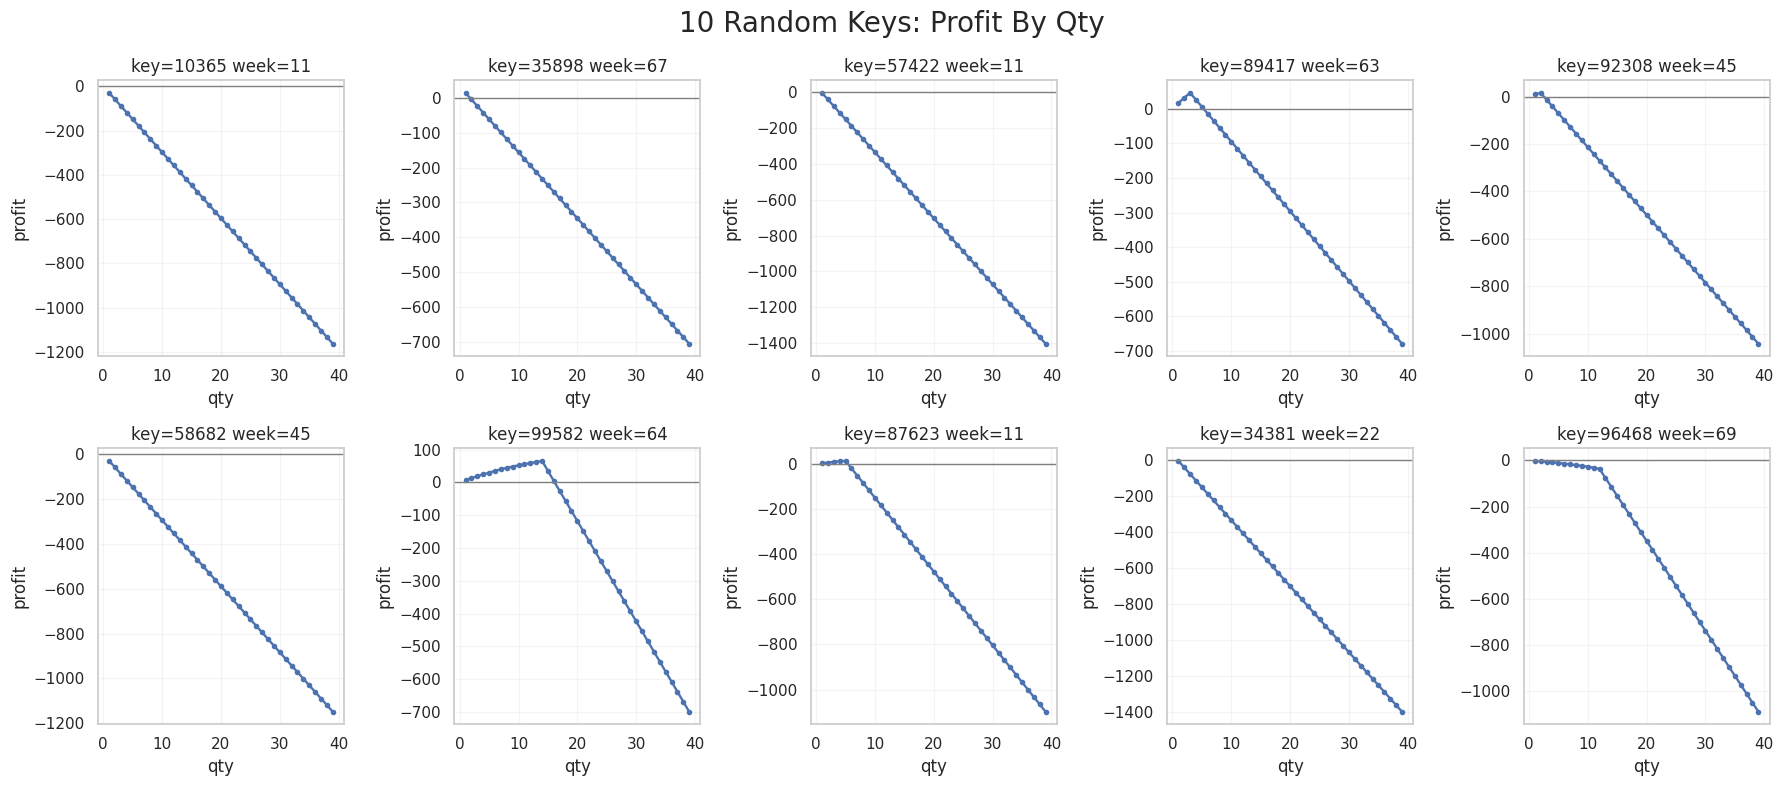

In [12]:
curve_df = train_all[train_all["segment"] == "observed"].copy()
keys_any = rng.choice(curve_df["key"].drop_duplicates(), size=min(10, curve_df["key"].nunique()), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8), squeeze=False)
for ax, key in zip(axes.ravel(), keys_any):
    key_df = curve_df[curve_df["key"] == key].sort_values("qty")
    ax.plot(key_df["qty"], key_df["profit"], marker="o", ms=3, lw=1.7)
    ax.axhline(0, c="gray", lw=1)
    ax.set_title(f"key={int(key)} week={int(key_df['date'].iloc[0])}")
    ax.set_xlabel("qty")
    ax.set_ylabel("profit")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(keys_any):]:
    ax.axis("off")
fig.suptitle("10 Random Keys: Profit By Qty", fontsize=20)
plt.tight_layout()

## Current Internal Drivers

These plots show the hidden time-varying market and policy drivers used by the simulator.

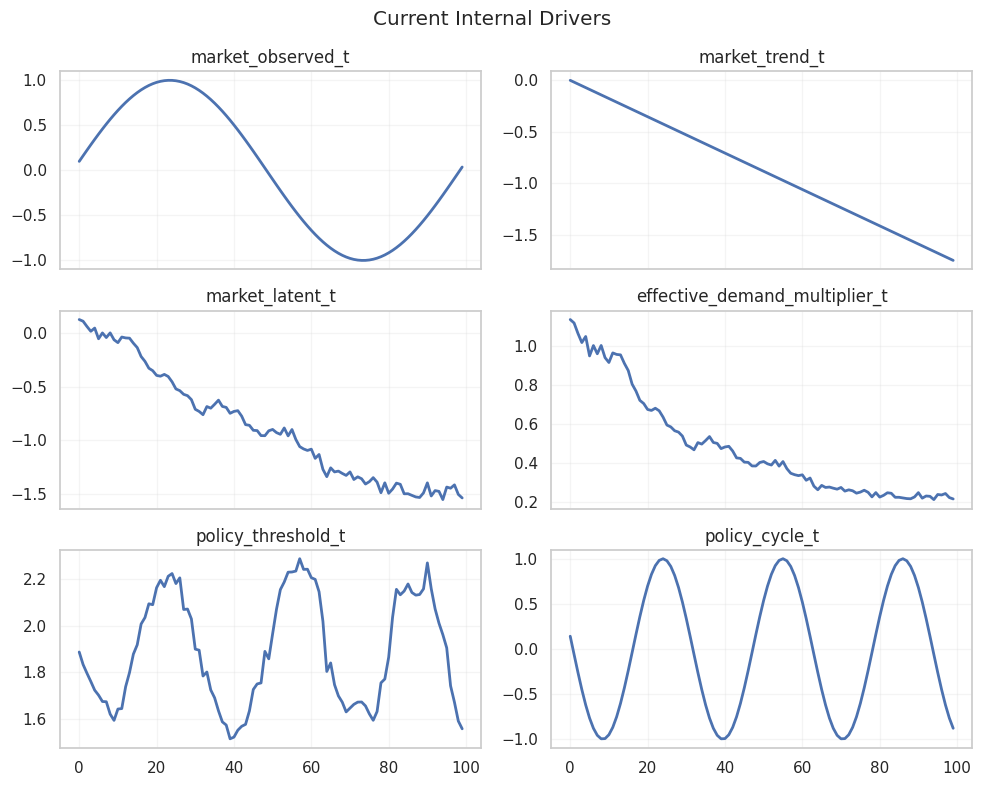

In [13]:
driver_df = inspection["date_process_df"]
driver_cols = [
    "market_observed_t",
    "market_trend_t",
    "market_latent_t",
    "effective_demand_multiplier_t",
    "policy_threshold_t",
    "policy_cycle_t",
]

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for ax, col in zip(axes.ravel(), driver_cols):
    ax.plot(driver_df["date"], driver_df[col], lw=2)
    ax.set_title(col)
    ax.grid(alpha=0.2)

fig.suptitle("Current Internal Drivers")
plt.tight_layout()

## Reducing Dataset to Business-Traded

This section converts the full synthetic market into the historical view that the business would actually have observed.

This is the key step that creates the realistic training limitation. The model is not trained on the full market. It is trained on business-observed data, meaning the rows that were selected or safely grounded by the historical business process.

In the paper's terms, this creates the biased historical business menu. The unobserved market still exists, but the model does not receive full labels for it.

In [14]:
business_observed_dataset = convert_market_dataset_state(
    market_dataset,
    to_state="historical",
)

## Industry Baseline

This section trains a conventional XGBoost classifier on business-observed data.

The target is whether realized profit is positive. The model is trained only on observed historical rows, using chronological splits for fitting, early stopping, and calibration.

This baseline represents what a capable business data-science team might build with standard tabular ML: train a strong model on historical labeled trades, predict which future trades are likely to be profitable, and select the best candidates.

The model should reach strong validation performance if the conventional baseline is learning signal inside the business-observed data. That means the later failure is more informative: the problem is not simply low model quality, but biased training data and deployment-time distribution mismatch.

In [15]:
BASELINE_EARLY_STOP_FRACTION = 0.20
BASELINE_CALIBRATION_FRACTION = 0.20
BASELINE_NAIVE_EVAL_FRACTION = 0.20
BASELINE_FEATURE_COLS = ["lcogs", "qty", "sv", "isv"]
XGB_DEVICE = "cuda"

frames = business_observed_dataset["frames"]
X = frames["X_labeled.parquet"].reset_index(drop=True)
y = frames["y_labeled.parquet"]["profit"].reset_index(drop=True).astype(float)
weeks = frames["x_labeled_dates.parquet"]["date"].reset_index(drop=True)
keys = frames["x_labeled_keys.parquet"]["key"].reset_index(drop=True)
missing_baseline_features = sorted(set(BASELINE_FEATURE_COLS) - set(X.columns))
baseline_feature_cols = BASELINE_FEATURE_COLS

# Train on business-observed rows only
business_observed_frame = X.copy()
business_observed_frame["profit"] = y
business_observed_frame["date"] = weeks
business_observed_frame["key"] = keys


# Keep naive evaluation before deploy-time eval, at the expense of sharing the
# early-stop and threshold-calibration holdout.
unique_weeks = sorted(weeks.unique())
n_early_stop_weeks = max(1, int(np.ceil(len(unique_weeks) * BASELINE_EARLY_STOP_FRACTION)))
n_calibration_weeks = max(1, int(np.ceil(len(unique_weeks) * BASELINE_CALIBRATION_FRACTION)))
n_naive_eval_weeks = max(1, int(np.ceil(len(unique_weeks) * BASELINE_NAIVE_EVAL_FRACTION)))
assert n_early_stop_weeks == n_calibration_weeks
assert n_early_stop_weeks + n_naive_eval_weeks < len(unique_weeks)
naive_eval_weeks = unique_weeks[-n_naive_eval_weeks:]
early_stop_weeks = unique_weeks[-(n_early_stop_weeks + n_naive_eval_weeks):-n_naive_eval_weeks]
calibration_weeks = early_stop_weeks
business_early_stop_mask = business_observed_frame["date"].isin(early_stop_weeks)
business_calibration_mask = business_observed_frame["date"].isin(calibration_weeks)
business_naive_eval_mask = business_observed_frame["date"].isin(naive_eval_weeks)
business_train_mask = ~(business_early_stop_mask | business_naive_eval_mask)
assert not (business_train_mask & business_early_stop_mask).any()
assert (business_early_stop_mask == business_calibration_mask).all()
assert not (business_train_mask & business_naive_eval_mask).any()
assert not (business_early_stop_mask & business_naive_eval_mask).any()

X_business_fit = business_observed_frame.loc[business_train_mask, baseline_feature_cols].astype("float32")
y_business_fit = business_observed_frame.loc[business_train_mask, "profit"]
X_business_early_stop = business_observed_frame.loc[business_early_stop_mask, baseline_feature_cols].astype("float32")
y_business_early_stop = business_observed_frame.loc[business_early_stop_mask, "profit"]
X_business_calibration = business_observed_frame.loc[business_calibration_mask, baseline_feature_cols].astype("float32")
X_business_naive_eval = business_observed_frame.loc[business_naive_eval_mask, baseline_feature_cols].astype("float32")

y_business_fit_binary = (y_business_fit > 0).astype(int)
y_business_early_stop_binary = (y_business_early_stop > 0).astype(int)

fit_pos = int(y_business_fit_binary.sum())
fit_neg = int(len(y_business_fit_binary) - fit_pos)
scale_pos_weight = max(1.0, fit_neg / max(1, fit_pos))
print(
    f"fit rows={len(X_business_fit):,}; early-stop rows={len(X_business_early_stop):,}; "
    f"calibration rows={len(X_business_calibration):,}; "
    f"naive-eval rows={len(X_business_naive_eval):,}; scale_pos_weight={scale_pos_weight:,.2f}"
)


# Define the XGBoost classifier setup
xgb_classifier_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_estimators=20000,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    random_state=random_state,
    n_jobs=-1,
    device=XGB_DEVICE,
    early_stopping_rounds=150,
)
xgb_classifier_baseline.fit(
    X_business_fit,
    y_business_fit_binary,
    eval_set=[(X_business_fit, y_business_fit_binary), (X_business_early_stop, y_business_early_stop_binary)],
    verbose=100,
)

print(f"best iteration={xgb_classifier_baseline.best_iteration:,}; early-stop AUC={xgb_classifier_baseline.best_score:,.4f}")

fit rows=6,202; early-stop rows=2,660; calibration rows=2,660; naive-eval rows=4,505; scale_pos_weight=1.00
[0]	validation_0-auc:0.94672	validation_1-auc:0.91597
[100]	validation_0-auc:0.95460	validation_1-auc:0.92192
[200]	validation_0-auc:0.95866	validation_1-auc:0.92305
[300]	validation_0-auc:0.95942	validation_1-auc:0.92517
[400]	validation_0-auc:0.96001	validation_1-auc:0.92549
[500]	validation_0-auc:0.96057	validation_1-auc:0.92643
[600]	validation_0-auc:0.96112	validation_1-auc:0.92667
[700]	validation_0-auc:0.96165	validation_1-auc:0.92731
[800]	validation_0-auc:0.96211	validation_1-auc:0.92828


[900]	validation_0-auc:0.96263	validation_1-auc:0.92816
[939]	validation_0-auc:0.96287	validation_1-auc:0.92813
best iteration=789; early-stop AUC=0.9284


In [16]:
# Metrics + predictions on the chronological early-stop holdout
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

y_true = y_business_early_stop_binary.to_numpy()
y_proba = xgb_classifier_baseline.predict_proba(X_business_early_stop)[:, 1]

roc_auc = roc_auc_score(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)
brier = brier_score_loss(y_true, y_proba)

print(f"Early-stop ROC-AUC: {roc_auc:.4f}")
print(f"Early-stop PR-AUC:  {pr_auc:.4f}")
print(f"Early-stop Brier:   {brier:.4f}")

Early-stop ROC-AUC: 0.9284
Early-stop PR-AUC:  0.9474
Early-stop Brier:   0.1002


/home/ivan/miniconda3/envs/parml313/lib/python3.13/site-packages/xgboost/core.py:774: UserWarning: [14:47:30] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


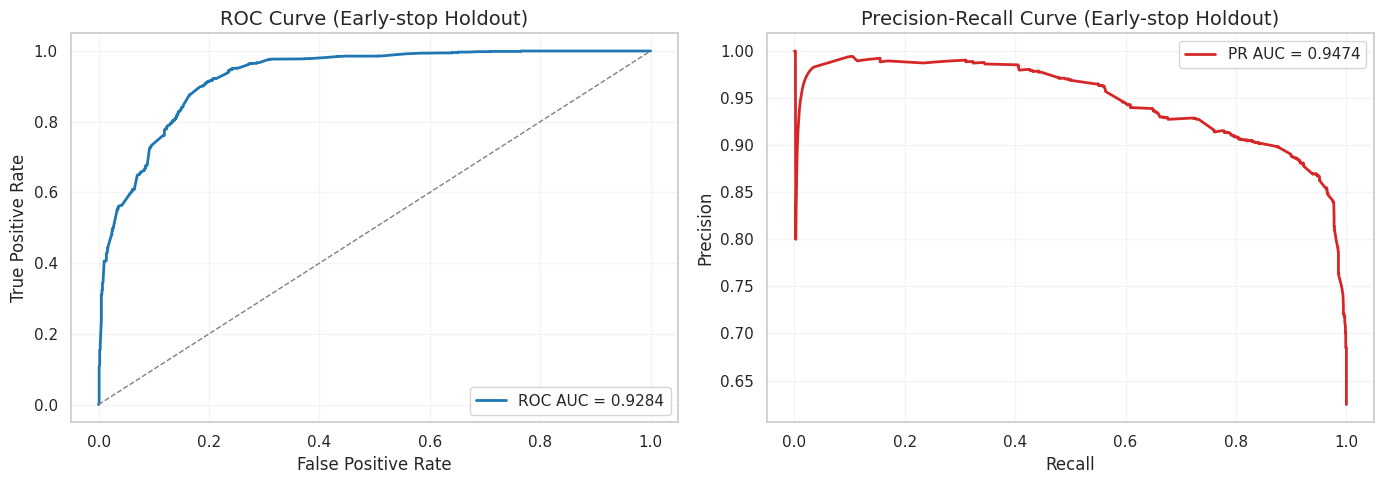

In [17]:
# AUC plots: ROC and Precision-Recall
fpr, tpr, _ = roc_curve(y_true, y_proba)
precision, recall, _ = precision_recall_curve(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, lw=2, color="#1f77b4", label=f"ROC AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
axes[0].set_title("ROC Curve (Early-stop Holdout)", fontsize=14)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(recall, precision, lw=2, color="#d62728", label=f"PR AUC = {pr_auc:.4f}")
axes[1].set_title("Precision-Recall Curve (Early-stop Holdout)", fontsize=14)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()

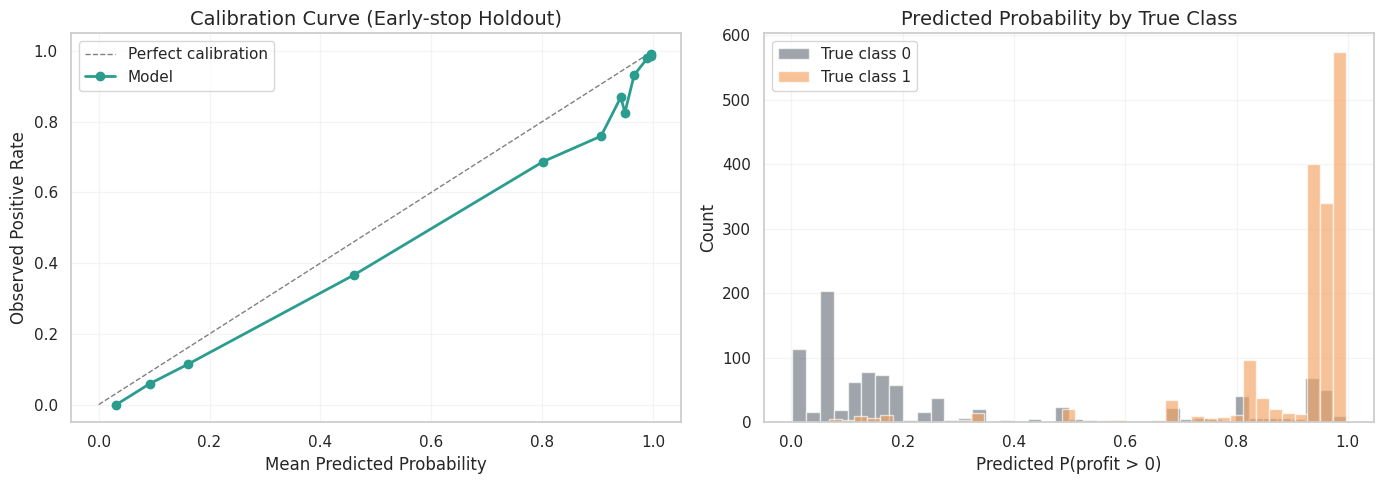

In [18]:
# Calibration plot (reliability diagram + score histogram)
frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=12, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
axes[0].plot(mean_pred, frac_pos, marker="o", lw=2, color="#2a9d8f", label="Model")
axes[0].set_title("Calibration Curve (Early-stop Holdout)", fontsize=14)
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Observed Positive Rate")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].hist(y_proba[y_true == 0], bins=40, alpha=0.65, label="True class 0", color="#6c757d")
axes[1].hist(y_proba[y_true == 1], bins=40, alpha=0.65, label="True class 1", color="#f4a261")
axes[1].set_title("Predicted Probability by True Class", fontsize=14)
axes[1].set_xlabel("Predicted P(profit > 0)")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()

## Calibrate the Classifier Threshold

This section calibrates the probability threshold used to decide whether the model should trade.

Instead of using a default threshold like `0.5`, the notebook scans thresholds on a held-out calibration period and chooses the cutoff that maximizes realized profit on selected rows.

This makes the baseline stronger and more realistic. The deploy-time failure cannot be dismissed as a bad threshold choice. The threshold was tuned on historical business-observed data, but that data still does not represent the full future deployment menu.

In [19]:
business_calibration_frame = business_observed_frame.loc[business_calibration_mask, ["date", "key", "profit"]].reset_index(drop=True)
business_calibration_frame["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(X_business_calibration)[:, 1]

calibration_best_per_key = (
    business_calibration_frame
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)
threshold_scan = (
    calibration_best_per_key
    .groupby("positive_profit_proba", dropna=False)
    .agg(profit=("profit", "sum"), keys=("key", "nunique"))
    .sort_index(ascending=False)
    .reset_index()
)
threshold_scan["selected_keys"] = threshold_scan["keys"].cumsum()
threshold_scan["profit_on_selected"] = threshold_scan["profit"].cumsum()
threshold_scan = pd.concat([
    pd.DataFrame({
        "positive_profit_proba": [np.nextafter(threshold_scan["positive_profit_proba"].max(), np.inf)],
        "profit": [0.0],
        "keys": [0],
        "selected_keys": [0],
        "profit_on_selected": [0.0],
    }),
    threshold_scan,
], ignore_index=True)
best_threshold_row = threshold_scan.sort_values(["profit_on_selected", "selected_keys"], ascending=[False, True]).iloc[0]
classifier_profit_threshold = (
    np.nextafter(calibration_best_per_key["positive_profit_proba"].max(), np.inf)
    if best_threshold_row["selected_keys"] == 0
    else np.nextafter(best_threshold_row["positive_profit_proba"], -np.inf)
)

print(
    f"calibrated threshold={classifier_profit_threshold:.6f}; "
    f"calibration profit on selected={best_threshold_row['profit_on_selected']:,.2f}"
)

calibrated threshold=0.818064; calibration profit on selected=48,817.30


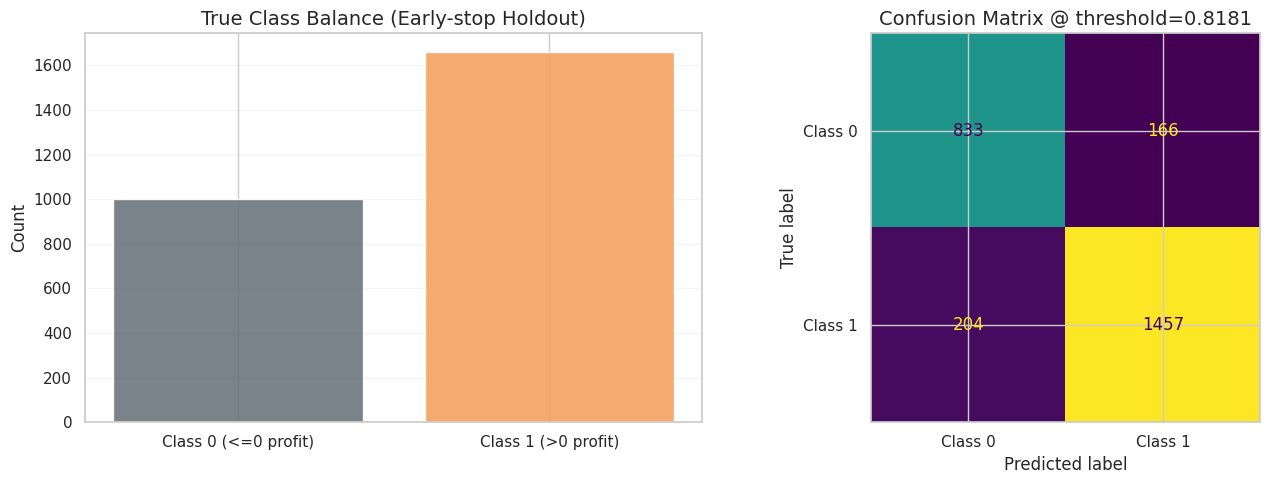

In [20]:
# Class plots: class balance + confusion matrix at your calibrated profit threshold
threshold_for_class_plot = float(classifier_profit_threshold)
y_pred = (y_proba > threshold_for_class_plot).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True class balance
class_counts = pd.Series(y_true).value_counts().sort_index()
axes[0].bar(["Class 0 (<=0 profit)", "Class 1 (>0 profit)"], class_counts.values, color=["#6c757d", "#f4a261"], alpha=0.9)
axes[0].set_title("True Class Balance (Early-stop Holdout)", fontsize=14)
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2, axis="y")

# Confusion matrix at selected threshold
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix @ threshold={threshold_for_class_plot:.4f}", fontsize=14)

plt.tight_layout()

## Naive Evaluation on Business-Traded

This section evaluates the model on the last historical business-observed block before deploy-time evaluation.

This is the optimistic evaluation. It asks: "If we only score the kind of trades the business historically selected or observed immediately before deployment, does the model make money?"

This looks like a successful model. It selects better than taking everything and better than doing nothing.

But this is not a true deployment test. It is still filtered through the business-observed subset. It does not test the model against the full opportunity menu that would be available at deployment time.

Total actual profit on model-selected: 61,879.42
Total actual profit Take-All: 27,430.54
Total actual profit Take-None: 0.00


,date,actual_profit_on_selected
0,64.0,6664.79
1,65.0,6819.29
2,66.0,5838.71
3,67.0,6587.22
4,68.0,5094.76
5,69.0,5337.61
6,70.0,5276.28
7,71.0,3741.26
8,72.0,3133.05
9,73.0,2689.85


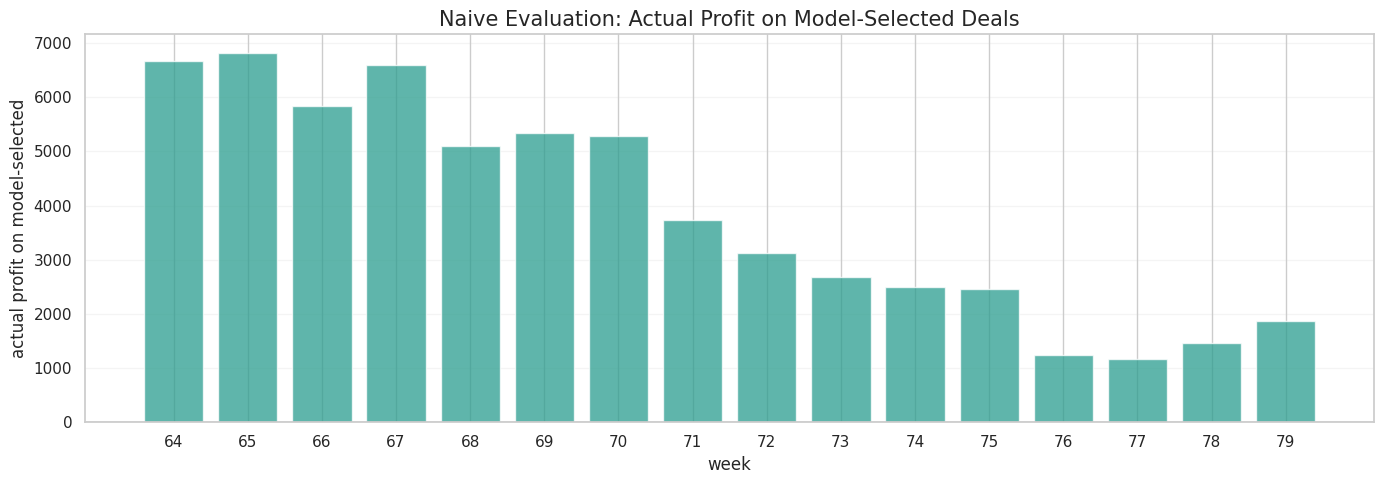

In [24]:
# Naive eval scores only business-observed rows in the historical block
# immediately before deploy-time evaluation.
xgb_classifier_naive_eval = (
    business_observed_frame
    .loc[business_naive_eval_mask, baseline_feature_cols + ["profit", "date", "key"]]
    .reset_index(drop=True)
    .copy()
)
xgb_classifier_naive_eval["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(
    X_business_naive_eval
)[:, 1]

# Apply the calibrated cutoff
xgb_classifier_naive_selected = (
    xgb_classifier_naive_eval[xgb_classifier_naive_eval["positive_profit_proba"] > classifier_profit_threshold]
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)
print(f"Total actual profit on model-selected: {xgb_classifier_naive_selected['profit'].sum():,.2f}")
print(f"Total actual profit Take-All: {xgb_classifier_naive_eval['profit'].sum():,.2f}")
print("Total actual profit Take-None: 0.00")

xgb_classifier_naive_by_week = (
    pd.DataFrame({"date": sorted(xgb_classifier_naive_eval["date"].unique())})
    .merge(
        xgb_classifier_naive_selected
        .groupby("date", dropna=False)
        .agg(actual_profit_on_selected=("profit", "sum")),
        on="date",
        how="left",
    )
    .fillna({"actual_profit_on_selected": 0.0})
)
display(xgb_classifier_naive_by_week.round(2))

fig, ax = plt.subplots(figsize=(14, 5))
colors = np.where(xgb_classifier_naive_by_week["actual_profit_on_selected"] >= 0, "#2a9d8f", "#d55e00")
ax.bar(
    xgb_classifier_naive_by_week["date"],
    xgb_classifier_naive_by_week["actual_profit_on_selected"],
    color=colors,
    alpha=0.75,
)
ax.axhline(0, c="gray", lw=1)
ax.set_title("Naive Evaluation: Actual Profit on Model-Selected Deals", fontsize=15)
ax.set_xlabel("week")
ax.set_ylabel("actual profit on model-selected")
ax.set_xticks(xgb_classifier_naive_by_week["date"])
ax.set_xticklabels([f"{int(date)}" for date in xgb_classifier_naive_by_week["date"]])
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()

## Deploy-Time Simulation Evaluation

This section performs the more important test.

Instead of scoring only business-observed rows, the model scores the full grounded future evaluation menu: both labeled and unlabeled candidate opportunities. This simulates what happens when the model is deployed and asked to choose from the broader opportunity set.

The same trained classifier and the same calibrated threshold are used. The only major change is the menu being scored.

This is the false-positive collapse. The model looked profitable on the naive business-observed evaluation, but when exposed to the full deployment-time menu, it selected many opportunities that appeared profitable according to the biased historical pattern and were actually negative.

This is exactly the failure mode P34 is designed to address. The lesson is that row-level predictive performance and calibrated thresholds are not enough. The model must reason about biased observation, unobserved alternatives, deployment-time menus, false-positive risk, and portfolio-level economics.

Total actual profit on model-selected: -425,410.32
Total actual profit Take-All: -521,713,014.88
Total actual profit Take-None: 0.00


,date,actual_profit_on_selected
0,80.0,-9477.80
1,81.0,-13166.37
2,82.0,-13305.82
3,83.0,-15029.81
4,84.0,-20701.84
5,85.0,-23819.34
6,86.0,-26979.20
7,87.0,-30930.73
8,88.0,-32862.33
9,89.0,-29950.26


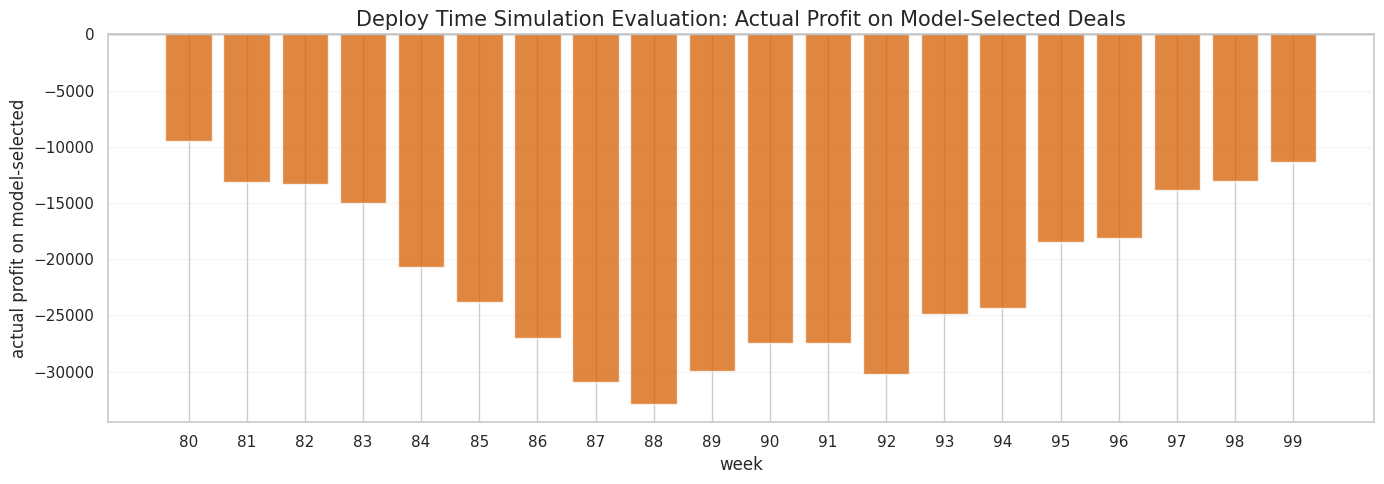

In [26]:
deploy_time_sim_eval = inspection["eval_all"].copy()

# Deploy-time simulation scores the full grounded eval menu
deploy_time_sim_eval["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(
    deploy_time_sim_eval[baseline_feature_cols].astype("float32")
)[:, 1]

# Apply the same cutoff, keep no more than one quantity option row per key
deploy_time_sim_selected = (
    deploy_time_sim_eval[deploy_time_sim_eval["positive_profit_proba"] > classifier_profit_threshold]
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)
print(f"Total actual profit on model-selected: {deploy_time_sim_selected['profit'].sum():,.2f}")
print(f"Total actual profit Take-All: {deploy_time_sim_eval['profit'].sum():,.2f}")
print("Total actual profit Take-None: 0.00")

deploy_time_sim_by_week = (
    pd.DataFrame({"date": sorted(deploy_time_sim_eval["date"].unique())})
    .merge(
        deploy_time_sim_selected.groupby("date", dropna=False).agg(actual_profit_on_selected=("profit", "sum")),
        on="date",
        how="left",
    )
    .fillna({"actual_profit_on_selected": 0.0})
)
display(deploy_time_sim_by_week.round(2))

fig, ax = plt.subplots(figsize=(14, 5))
colors = np.where(deploy_time_sim_by_week["actual_profit_on_selected"] >= 0, "#2a9d8f", "#d55e00")
ax.bar(deploy_time_sim_by_week["date"], deploy_time_sim_by_week["actual_profit_on_selected"], color=colors, alpha=0.75)
ax.axhline(0, c="gray", lw=1)
ax.set_title("Deploy Time Simulation Evaluation: Actual Profit on Model-Selected Deals", fontsize=15)
ax.set_xlabel("week")
ax.set_ylabel("actual profit on model-selected")
ax.set_xticks(deploy_time_sim_by_week["date"])
ax.set_xticklabels([f"{int(date)}" for date in deploy_time_sim_by_week["date"]])
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()

## Interpretation

This notebook demonstrates why the P34 paper argues for Profit-As-Regression Machine Learning rather than ordinary prediction.

A conventional classifier can learn a strong signal inside the historically observed business data. It can pass validation, calibrate well, and make money in a naive holdout test. But if the historical labels are created by a biased prior policy, the model may not understand the unobserved opportunity distribution.

At deployment time, the model is no longer protected by the historical business policy. It sees many more candidates. Some of them resemble profitable historical trades in feature space, but they belong to a different part of the market distribution. These are false positives.

The paper's P34 architecture addresses this by treating the business menu itself as the modeling object. Instead of only asking whether individual rows look profitable, P34 is designed to evaluate candidate portfolios under partial observability, construct plausible interpretations of missing data, account for regime drift, correct false-positive risk, and allow no-trade as a valid decision.

This notebook therefore serves as a clean diagnostic example: it shows why a standard industry baseline can appear successful in a biased historical test while failing in a realistic deploy-time simulation.


# Demo Results of P34 on same market

The cells below are for draft reference only and to demonstrate results, pending stabilization of P34 API and public API release. For baseline comparison, we used an advanced regressor-based approach as we believe using industry-naive calibrated classifier is not a fair demonstration since this approach never generates a profitable trade portfolio on this simulated market deployment.

In [23]:
base_path = VALIDATION_DATA_PATH

x_grounded_dates_val = pd.read_parquet(f"{base_path}/x_labeled_dates.parquet")
x_grounded_keys_val = pd.read_parquet(f"{base_path}/x_labeled_keys.parquet")
X_grounded_val = pd.read_parquet(f"{base_path}/X_labeled.parquet")
x_grounded_deployment_unlabeled_dates_val = pd.read_parquet(f"{base_path}/x_unlabeled_dates.parquet")
x_grounded_deployment_unlabeled_keys_val = pd.read_parquet(f"{base_path}/x_unlabeled_keys.parquet")
X_grounded_deployment_unlabeled_val = pd.read_parquet(f"{base_path}/X_unlabeled.parquet")
y_grounded_val = pd.read_parquet(f"{base_path}/y_labeled.parquet")
y_grounded_deployment_unlabeled_val = pd.read_parquet(f"{base_path}/y_unlabeled.parquet")

x_grounded_dates_val = pd.concat([x_grounded_dates_val, x_grounded_deployment_unlabeled_dates_val], axis=0).reset_index(drop=True)
x_grounded_keys_val = pd.concat([x_grounded_keys_val, x_grounded_deployment_unlabeled_keys_val], axis=0).reset_index(drop=True)
X_grounded_val = pd.concat([X_grounded_val, X_grounded_deployment_unlabeled_val], axis=0).reset_index(drop=True)
y_grounded_val = pd.concat([y_grounded_val, y_grounded_deployment_unlabeled_val], axis=0).reset_index(drop=True)    

Xy_bagged_test_df = X_grounded_val.copy()
Xy_bagged_test_df["key"] = x_grounded_keys_val["key"]
Xy_bagged_test_df["bag_id"] = x_grounded_dates_val["date"]
Xy_bagged_test_df["profit"] = y_grounded_val["profit"]

GOOD_FEATURES = X_grounded_val.columns.tolist()

NameError: name 'VALIDATION_DATA_PATH' is not defined

In [ ]:
import datetime
run_id = datetime.datetime.now().isoformat()

unique_bag_ids_test = list(Xy_bagged_test_df["bag_id"].unique())
print(f"Unique bag_ids in test set: {len(unique_bag_ids_test)}")
random.seed(42)  # for reproducibility of bag sampling order
random.shuffle(unique_bag_ids_test)  # shuffle bag ids to avoid any order bias in testing

all_profits_no_gr = []
all_profits_no_gr_predicted = []
no_gr_selected_counts = []
all_profits_policy = []
all_profits_policy_predicted = []
policy_selected_counts = []
all_max_possible_gt_0_profit = []
max_selected_counts = []


PROBA_THRESHOLD = 0.5
feature_cols = []

# for bag_id in unique_bag_ids_test[:int(0.1*len(unique_bag_ids_test))]:  # test on first 10% of bags for speed
for bag_id in unique_bag_ids_test:  
# for bag_id in [one_selected_date]:  # test on single bag for debugging
    bag_df = Xy_bagged_test_df[
        Xy_bagged_test_df["bag_id"] == bag_id
    ].copy()

    if len(bag_df) == 0:
        continue

    # ------------------------------------------------------------
    # Build aligned bag_samples and residuals_X using GOOD_FEATURES
    # as composite unique identifier
    # ------------------------------------------------------------
    bag_samples = bag_df.drop_duplicates(subset=GOOD_FEATURES, keep="first").copy()

    preds_no_gr = baseline_regressor.predict(
        bag_samples[GOOD_FEATURES]
    )

    policy_profit_preds_df = fit_model.predict(
        X_fully_grounded_menu=bag_samples[GOOD_FEATURES],
        x_fully_grounded_menu_dates=pd.DataFrame(np.zeros(len(bag_samples)), columns=["date"], index=bag_samples.index),  # placeholder if your model needs dates
        x_fully_grounded_menu_keys=bag_samples[["key"]],
        # market_efficiency_override=1.0  # 0.5= basically UL is off
    )

    if len(policy_profit_preds_df):
        policy_predicted_profit_sum = policy_profit_preds_df["profit"].sum()
    else:
        policy_predicted_profit_sum = 0
    policy_actual_profit_sum = 0

    policy_selected_count = 0

    for _id, row in policy_profit_preds_df.iterrows():
        if row["qty"] <= 0:
            continue  # skip zero quantity selections
        profit = bag_df[(bag_df["key"] == row["key"]) & (bag_df["qty"] == row["qty"])]["profit"].sum()
        policy_actual_profit_sum += profit
        policy_selected_count += 1

    policy_selected_counts.append(policy_selected_count)
    bag_df["__pred_no_gr__"] = preds_no_gr

    no_gr_predicted_profit_sum = 0
    no_gr_actual_profit_sum = 0
    no_gr_selected_count = 0
    for key_id, group in bag_df.groupby("key"):
        max_pred_no_gr_for_key = group["__pred_no_gr__"].max()
        if max_pred_no_gr_for_key <= 0:
            continue  # only consider predicted positive profit for the no-grounding regressor
        no_gr_predicted_profit_sum += max_pred_no_gr_for_key
        max_pred_no_gr_idx = group["__pred_no_gr__"].idxmax()
        actual_profit_for_key = group.loc[max_pred_no_gr_idx, "profit"]
        no_gr_actual_profit_sum += actual_profit_for_key
        no_gr_selected_count += 1

    # calculate max possible profit on this bag (profit > 0)
    max_possible_gt_0_profit = 0
    max_selected_count = 0
    for key_id, group in bag_df.groupby("key"):
        actual_max_profit = group.loc[group["profit"].idxmax(), "profit"]
        max_possible_gt_0_profit += max(0, actual_max_profit)
        if actual_max_profit > 0:
            max_selected_count += 1
    
    all_profits_no_gr.append(no_gr_actual_profit_sum)
    all_profits_no_gr_predicted.append(no_gr_predicted_profit_sum)
    all_profits_policy.append(policy_actual_profit_sum)
    all_profits_policy_predicted.append(policy_predicted_profit_sum)
    all_max_possible_gt_0_profit.append(max_possible_gt_0_profit)

    print(
        f"Bag ID: {bag_id}, "
        f"positive_sum_of actuals _no_gr: {no_gr_actual_profit_sum}, "
        f"positive_sum_of_policy_selected: {policy_actual_profit_sum}, "
        f"Predicted positive sum (no_gr): {no_gr_predicted_profit_sum}, "
        f"Predicted positive sum (policy): {policy_predicted_profit_sum}, "
        f"max possible profit (profit > 0) = {max_possible_gt_0_profit:.4f}, "
        f"no_gr selected count = {no_gr_selected_count}, "
        f"policy selected count = {policy_selected_count}, "
        f"max possible selected count = {max_selected_count}, "
        f"total count in bag = {len(bag_df)}"
    )

    no_gr_selected_counts.append(no_gr_selected_count)
    policy_selected_counts.append(policy_selected_count)
    max_selected_counts.append(max_selected_count)

Unique bag_ids in test set: 20


Bag ID: 99.0, positive_sum_of actuals _no_gr: -2704.243627595047, positive_sum_of_policy_selected: -256.3301888727127, Predicted positive sum (no_gr): 2411.202392578125, Predicted positive sum (policy): 1393.0034595622528, max possible profit (profit > 0) = 1906.0040, no_gr selected count = 117, policy selected count = 105, max possible selected count = 96, total count in bag = 17550


Bag ID: 85.0, positive_sum_of actuals _no_gr: -3494.226637963461, positive_sum_of_policy_selected: 1747.992945412177, Predicted positive sum (no_gr): 11038.259765625, Predicted positive sum (policy): 8545.567217523138, max possible profit (profit > 0) = 11122.6730, no_gr selected count = 376, policy selected count = 281, max possible selected count = 326, total count in bag = 52650


Bag ID: 94.0, positive_sum_of actuals _no_gr: -5513.888598030731, positive_sum_of_policy_selected: -45.38851130816866, Predicted positive sum (no_gr): 8342.8408203125, Predicted positive sum (policy): 6171.139099042912, max possible profit (profit > 0) = 7330.0308, no_gr selected count = 315, policy selected count = 238, max possible selected count = 288, total count in bag = 46800


Bag ID: 84.0, positive_sum_of actuals _no_gr: -2098.1154092810766, positive_sum_of_policy_selected: 1307.1419906057088, Predicted positive sum (no_gr): 10091.123046875, Predicted positive sum (policy): 8105.99354409533, max possible profit (profit > 0) = 9823.7913, no_gr selected count = 343, policy selected count = 321, max possible selected count = 319, total count in bag = 46800


...

Bag ID: 96.0, positive_sum_of actuals _no_gr: -3951.826242877685, positive_sum_of_policy_selected: -605.7224315668863, Predicted positive sum (no_gr): 5485.73583984375, Predicted positive sum (policy): 4365.7921027736265, max possible profit (profit > 0) = 5142.4767, no_gr selected count = 240, policy selected count = 213, max possible selected count = 235, total count in bag = 35100


Bag ID: 87.0, positive_sum_of actuals _no_gr: -6398.836761461256, positive_sum_of_policy_selected: 392.7150165386137, Predicted positive sum (no_gr): 13355.6181640625, Predicted positive sum (policy): 10399.92727771122, max possible profit (profit > 0) = 12590.0219, no_gr selected count = 476, policy selected count = 428, max possible selected count = 435, total count in bag = 64350


Bag ID: 88.0, positive_sum_of actuals _no_gr: -7069.756410753935, positive_sum_of_policy_selected: 61.91579184104177, Predicted positive sum (no_gr): 13690.34765625, Predicted positive sum (policy): 10372.934738952667, max possible profit (profit > 0) = 12061.4192, no_gr selected count = 462, policy selected count = 358, max possible selected count = 403, total count in bag = 64350


Bag ID: 80.0, positive_sum_of actuals _no_gr: -82.3544189419349, positive_sum_of_policy_selected: 1704.2436611256182, Predicted positive sum (no_gr): 5139.47900390625, Predicted positive sum (policy): 4099.567417830157, max possible profit (profit > 0) = 5237.9427, no_gr selected count = 168, policy selected count = 149, max possible selected count = 155, total count in bag = 23400


Bag ID: 83.0, positive_sum_of actuals _no_gr: 890.134148694337, positive_sum_of_policy_selected: 3116.45598030373, Predicted positive sum (no_gr): 9312.865234375, Predicted positive sum (policy): 7474.565766238687, max possible profit (profit > 0) = 9923.1167, no_gr selected count = 290, policy selected count = 262, max possible selected count = 278, total count in bag = 40950


In [ ]:
print(f"Total profit sum (state-of-art business grounded GBDT-R): {sum(all_profits_no_gr):.2f}")
print(f" -- total predicted (state-of-art business grounded GBDT-R): {sum(all_profits_no_gr_predicted):.2f}")
print(f"Total profit sum (HyperC PARML-P34-2): {sum(all_profits_policy):.2f}")
print(f" -- total predicted (HyperC PARML-P34-2): {sum(all_profits_policy_predicted):.2f}")
print(f" -- prediction accuracy (PARML-P34-2 vs actual): {sum(all_profits_policy) / sum(all_profits_policy_predicted) * 100 if sum(all_profits_policy_predicted) > 0 else 0:.2f}%")
print(f" -- trade success s%n (PARML-P34-2 predicted profit > 0): {sum(np.array(all_profits_policy) > 0) / len(all_profits_policy_predicted) * 100:.2f}%")
print(f"Total max possible profit on labeled market (profit > 0): {sum(all_max_possible_gt_0_profit):.2f}")
print(f" -- market efficiency (PARML-P34-2 vs max possible profit): {sum(all_profits_policy) / sum(all_max_possible_gt_0_profit) * 100 if sum(all_max_possible_gt_0_profit) > 0 else 0:.2f}%")

Total profit sum (state-of-art business grounded GBDT-R): -62625.84
 -- total predicted (state-of-art business grounded GBDT-R): 179152.70
Total profit sum (HyperC PARML-P34-2): 25846.86
 -- total predicted (HyperC PARML-P34-2): 132746.87
 -- prediction accuracy (PARML-P34-2 vs actual): 19.47%
 -- trade success s%n (PARML-P34-2 predicted profit > 0): 80.00%
Total max possible profit on labeled market (profit > 0): 173530.86
 -- market efficiency (PARML-P34-2 vs max possible profit): 14.89%


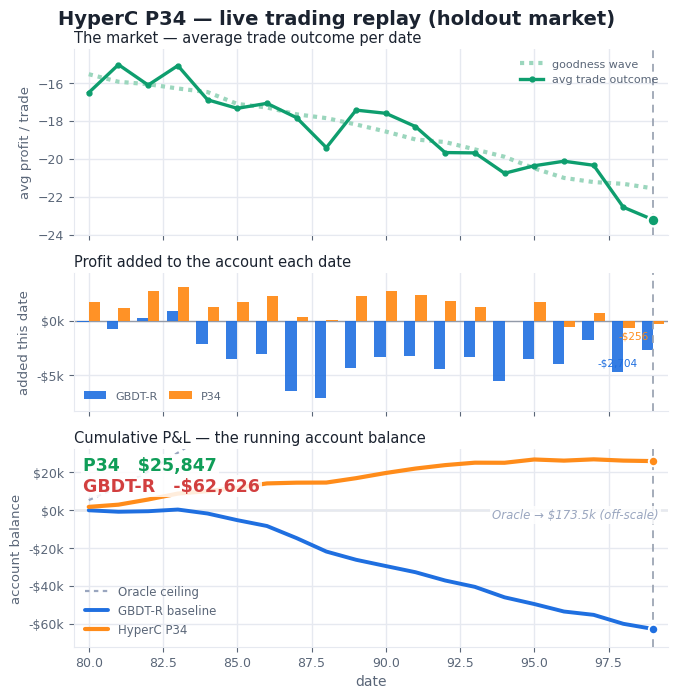

In [ ]:
fig, axes = rc.make_figure(d)
rc.draw_frame(len(d['vd']), d, axes)   # k = last date -> full picture
plt.show()   # single static PNG (no duplicate repr) for the GitHub viewer

# Conclusion

In this feature demonstration, we see that P34 was able to gain profit on the falling market while other approaches a business would take using state-of-art available tooling would fail to interpret unobseved market behaviour, and subsequently fail to yield a positive ROI.

Additionally, in this demonstration we pushed our pre-release version of P34 to the limits, so its prediction accuracy dropped below 20%. This is not a nominal performance and is subject for improvement as we train a more capable model.

For more information, please visit https://hyperc.com  
for inquiries, please email us at info@hyperc.com